In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cm
from scipy.spatial import KDTree
from mpl_toolkits.axes_grid1 import make_axes_locatable

# extracting data from plot

In [64]:
# read plot image
im = mpimg.imread("c.png")
im = np.flip(im,axis=0)
# get the RGB color arrays, im[:,:,3] is transparency
rgb_image = im[:,:,:3]

# make a lut -- look up table for viridis cmap
viridis = cm.get_cmap('viridis', 256)
lut = viridis(np.linspace(0, 1, 256))[:, :3]

# reshape image for query
pixels = rgb_image.reshape(-1, 3)
# kd-tree for quick nearest-neighbor lookup, return position in lut array
tree = KDTree(lut)
_, indices = tree.query(pixels)
# reshape back to 2D
data_2d = indices.reshape(rgb_image.shape[0], rgb_image.shape[1])
# Scale to the actual units (0.0 to 0.8 according to paper colorbar)
final_data = (data_2d / 255.0) * 0.8
# final_data = np.flip(final_data,axis=0)

/tmp/ipykernel_581/3045379517.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 256)


# sample data

In [78]:
nq,npix = final_data.shape
# conversion from indices to paper ticks
ip = npix/200
iq = nq/100
# mesh with sampling indices
pcoords = np.arange(0,npix,25)[1:]-1
qcoords = np.arange(0,nq,20)[1:]-3
PIX,Q = np.meshgrid(pcoords,qcoords)
# sample data
csamp = np.array([final_data[y,x] for x,y in zip(PIX,Q)])

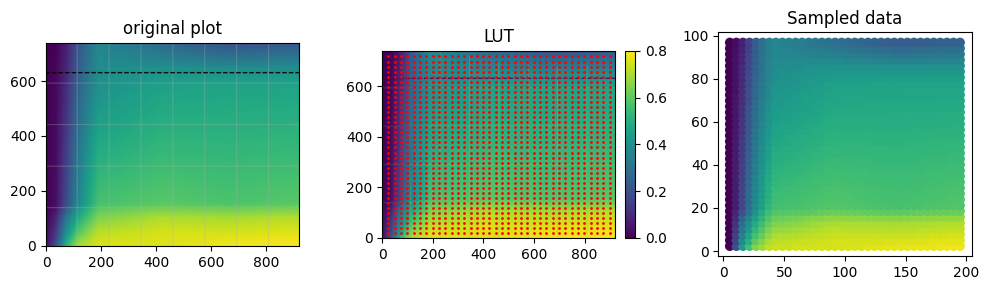

In [79]:
fig,ax = plt.subplots(1,3,figsize=(10,3))

ax[0].imshow(im,origin='lower')
ax[0].set_title("original plot")

im1 = ax[1].imshow(final_data,vmax=0.8,origin='lower')
ax[1].set_title("LUT")
div1 = make_axes_locatable(ax[1])
cax1 = div1.append_axes('right',0.1,pad=0.1)
# plot sampling grid
[ax[1].scatter(x,y,s=1,c='r') for x,y in zip(PIX,Q)]

# plot sampled points
[ax[2].scatter(x/ip,y/iq,c=c,cmap='viridis',vmax=0.8) for x,y,c in zip(PIX,Q,csamp)]
ax[2].set_title("Sampled data")

fig.colorbar(im1,cax=cax1,shrink=0.5)
fig.tight_layout();

''

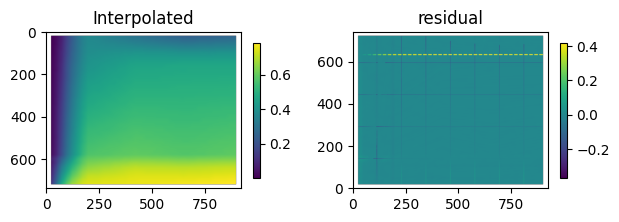

In [98]:
from scipy.interpolate import LinearNDInterpolator
# flattening for interpolation
pflat = PIX.ravel()
qflat = Q.ravel()
cflat = final_data.ravel()
# 2d interpolation
interp = LinearNDInterpolator(list(zip(qflat,pflat)),csamp.ravel())
# inverse x,y here (compare to paper) bc imshow flips it?
X,Y = np.meshgrid(np.arange(nq),np.arange(npix))
Z = interp(X,Y)
# plot
fig,ax = plt.subplots(1,2)
im0=ax[0].imshow(np.flip(Z.T,axis=0))
im1=ax[1].imshow(Z.T-final_data,origin='lower')

ax[0].set_title("Interpolated")
ax[1].set_title("residual")
[fig.colorbar(i,shrink=0.3) for i in [im0,im1]]
fig.tight_layout()
;